In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from src import proccess_data

import optuna

In [26]:
df = pd.read_csv('../data/small_sample.csv')

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52271 entries, 0 to 52270
Columns: 1369 entries, Unnamed: 0 to feature_1366
dtypes: float64(1361), int64(8)
memory usage: 546.0 MB


In [25]:
df.to_csv('../data/small_sample.csv')

In [29]:
df = df.drop(['Unnamed: 0'], axis=1)


df.head()

,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
0,0.0,0.5,0.5,1.0,1.0,1.0,2.0,1.0,2.0,0.0,...,0.0,0.0,0.0,1,0,0,0,0,0,0
1,0.0,0.5,0.5,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,-1.0,-1.0,-1.0,1,1,1,0,1,1,1
2,0.0,0.5,0.5,1.0,1.0,2.0,3.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0.0,0.5,0.5,1.0,1.0,1.0,0.0,3.0,0.0,0.0,...,-1.0,-1.0,-1.0,1,0,0,0,1,0,1
4,0.0,0.5,0.5,1.0,1.0,2.0,1.0,1.0,5.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


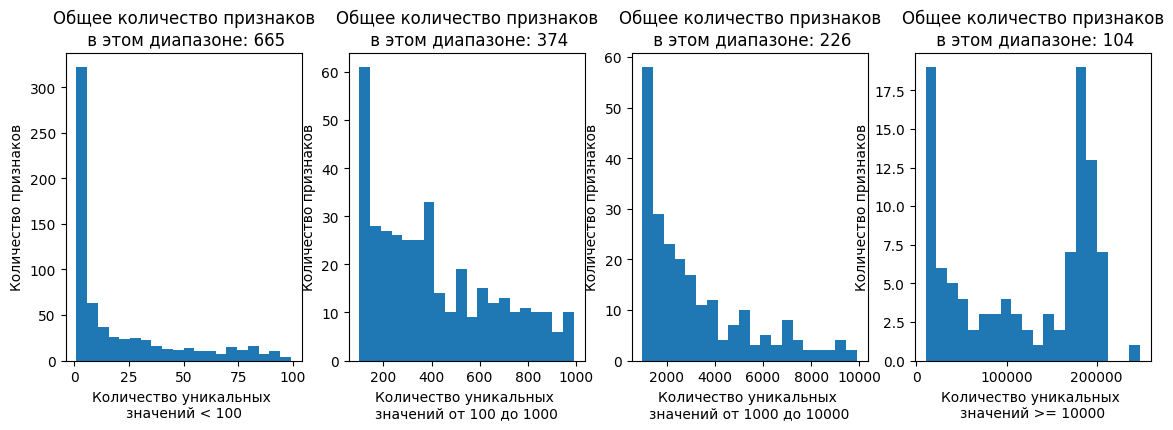

In [6]:
uniq_values = {col: df[col].unique() for col in df.columns}

num_of_unique_values = np.array([len(df[col].unique()) for col in df.columns])

fig, ax = plt.subplots(1, 4, figsize=(14, 4))

num_of_uniq_filt = num_of_unique_values[num_of_unique_values < 100]
ax[0].hist(list(num_of_uniq_filt), bins=20)
ax[0].set_xlabel("Количество уникальных \nзначений < 100")
ax[0].set_ylabel("Количество признаков")
ax[0].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 100) & (num_of_unique_values < 1000)]
ax[1].hist(list(num_of_uniq_filt), bins=20)
ax[1].set_xlabel("Количество уникальных \nзначений от 100 до 1000")
ax[1].set_ylabel("Количество признаков")
ax[1].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 1000) & (num_of_unique_values < 10000)]
ax[2].hist(list(num_of_uniq_filt), bins=20)
ax[2].set_xlabel("Количество уникальных \nзначений от 1000 до 10000")
ax[2].set_ylabel("Количество признаков")
ax[2].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))


num_of_uniq_filt = num_of_unique_values[num_of_unique_values >= 10000]
ax[3].hist(list(num_of_uniq_filt), bins=20)
ax[3].set_xlabel("Количество уникальных \nзначений >= 10000")
ax[3].set_ylabel("Количество признаков")
ax[3].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))


plt.show()
None


бОльшая часть признаков имеют дискретное распределение, меньше 100 признаков имеют непрерывное распределение 

In [30]:
X, y = df.drop(columns=['target']), df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

print(y_test.value_counts(), y_train.value_counts())


target
0.0    9792
1.0     663
Name: count, dtype: int64 target
0.0    39133
1.0     2683
Name: count, dtype: int64


In [31]:

model = CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=8, verbose=False, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))



              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      9792
         1.0       0.00      0.00      0.00       663

    accuracy                           0.94     10455
   macro avg       0.47      0.50      0.48     10455
weighted avg       0.88      0.94      0.91     10455

Confusion Matrix:
 [[9792    0]
 [ 663    0]]
ROC AUC Score: 0.6671687387247508


c:\dev\ml-project-adaai_VK_predict_hackaton\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev\ml-project-adaai_VK_predict_hackaton\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev\ml-project-adaai_VK_predict_hackaton\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

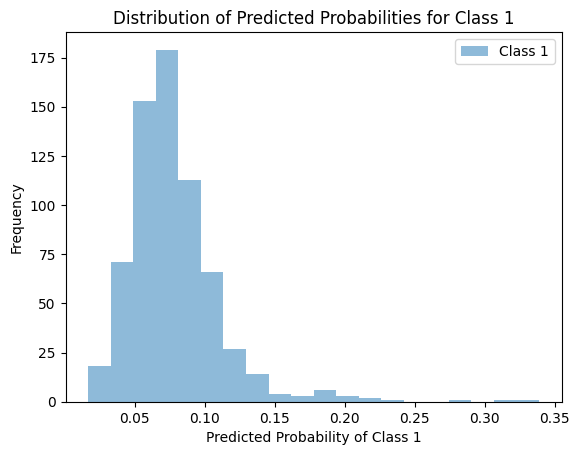

In [32]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
class1_test = y_test[y_test == 1]
class1_pred_proba = y_pred_proba[y_test == 1]
plt.hist(class1_pred_proba, bins=20, alpha=0.5, label='Class 1')
plt.xlabel('Predicted Probability of Class 1')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities for Class 1')
plt.legend()
plt.show()
None

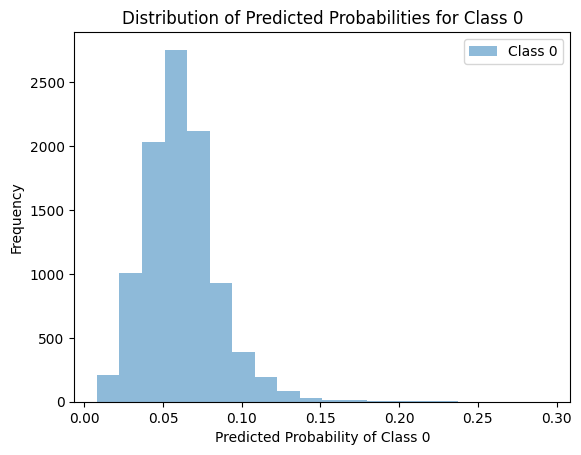

In [33]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
class1_test = y_test[y_test == 0]
class1_pred_proba = y_pred_proba[y_test == 0]
plt.hist(class1_pred_proba, bins=20, alpha=0.5, label='Class 0')
plt.xlabel('Predicted Probability of Class 0')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities for Class 0')
plt.legend()
plt.show()
None

катбуст не смог правильно классифицировать большинство объектов класса 1, данные имеют более хитрую структуру, распределения класса 0 и 1 на первый взгляд очень похожи

In [46]:
feature_importances = model.get_feature_importance(prettified=True)
print(feature_importances.tail())
eps = 0.7

df_importance = feature_importances[feature_importances['Importances'] > eps]
df_importance.shape


      Feature Id  Importances
100  feature_482     0.434766
101   feature_86     0.425018
102  feature_379     0.416449
103  feature_463     0.407257
104  feature_263     0.246781


(76, 2)

In [47]:
df_importance.tail()

,Feature Id,Importances
71,feature_1078,0.776525
72,feature_1120,0.776353
73,feature_383,0.765011
74,feature_45,0.746899
75,feature_343,0.700977


In [48]:
important_features = df_importance['Feature Id'].tolist()

important_features.append('target')

df_clean = df[important_features]

In [49]:
df_clean.head()

,feature_41,feature_16,feature_1094,feature_11,feature_43,feature_1076,feature_1205,feature_1122,feature_337,feature_44,...,feature_1109,feature_35,feature_805,feature_1113,feature_1078,feature_1120,feature_383,feature_45,feature_343,target
0,0.735702,0.548376,0.479959,0.767927,0.395097,0.130084,0.0,0.40,0.000000,0.736835,...,47.0,0.460173,2187.000000,26.0,0.064987,41.0,3762.000000,0.490412,0.000000,0.0
1,0.735702,0.548376,0.181833,0.767927,0.395097,0.035909,-1.0,0.20,1.241387,0.736835,...,-1.0,0.460173,843.942699,-1.0,0.030565,-1.0,111.769346,0.490412,0.469456,0.0
2,1.052307,0.900000,0.039433,0.733756,0.974415,0.046512,0.0,0.55,8.000000,0.585600,...,47.0,1.250000,19844.000000,27.0,0.007384,41.0,1274.000000,0.402557,0.000000,0.0
3,0.735702,0.548376,0.181833,0.767927,0.395097,0.035909,-1.0,0.56,10.000000,0.736835,...,46.0,0.460173,0.000000,26.0,0.030565,39.0,16.000000,0.490412,0.000000,0.0
4,0.638336,0.775862,0.466164,0.535792,0.195754,0.027359,0.0,0.47,0.000000,0.473383,...,47.0,0.222222,82.000000,27.0,0.023704,40.0,801.000000,0.314447,0.000000,0.0


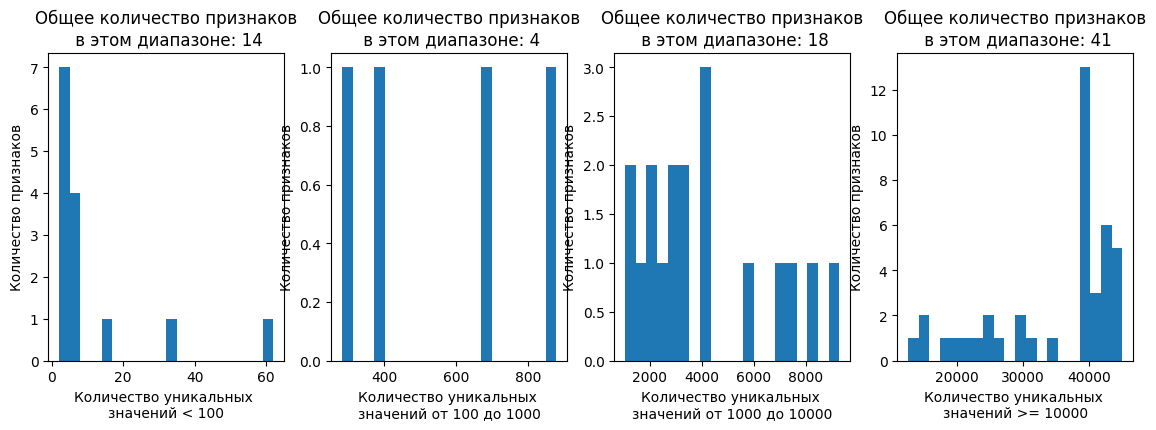

In [50]:
uniq_values = {col: df_clean[col].unique() for col in df_clean.columns}

num_of_unique_values = np.array([len(df_clean[col].unique()) for col in df_clean.columns])

fig, ax = plt.subplots(1, 4, figsize=(14, 4))

num_of_uniq_filt = num_of_unique_values[num_of_unique_values < 100]
ax[0].hist(list(num_of_uniq_filt), bins=20)
ax[0].set_xlabel("Количество уникальных \nзначений < 100")
ax[0].set_ylabel("Количество признаков")
ax[0].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 100) & (num_of_unique_values < 1000)]
ax[1].hist(list(num_of_uniq_filt), bins=20)
ax[1].set_xlabel("Количество уникальных \nзначений от 100 до 1000")
ax[1].set_ylabel("Количество признаков")
ax[1].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))

num_of_uniq_filt = num_of_unique_values[(num_of_unique_values >= 1000) & (num_of_unique_values < 10000)]
ax[2].hist(list(num_of_uniq_filt), bins=20)
ax[2].set_xlabel("Количество уникальных \nзначений от 1000 до 10000")
ax[2].set_ylabel("Количество признаков")
ax[2].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))


num_of_uniq_filt = num_of_unique_values[num_of_unique_values >= 10000]
ax[3].hist(list(num_of_uniq_filt), bins=20)
ax[3].set_xlabel("Количество уникальных \nзначений >= 10000")
ax[3].set_ylabel("Количество признаков")
ax[3].set_title("Общее количество признаков\n в этом диапазоне: " + str(len(num_of_uniq_filt)))


plt.show()
None

большинство важных фичей имеют более 100 уникальных значений, что вероятно показывает их непрерывное распределение, а не категориальное. Это может объяснять их важность для модели, так как непрерывные признаки могут содержать больше информации для классификации.

In [51]:
X, y = df_clean.drop(columns=['target']), df_clean['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

print(y_test.value_counts(), y_train.value_counts())

target
0.0    9792
1.0     663
Name: count, dtype: int64 target
0.0    39133
1.0     2683
Name: count, dtype: int64


In [52]:

model = CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=8, verbose=False, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))



              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97      9792
         1.0       1.00      0.00      0.01       663

    accuracy                           0.94     10455
   macro avg       0.97      0.50      0.49     10455
weighted avg       0.94      0.94      0.91     10455

Confusion Matrix:
 [[9792    0]
 [ 661    2]]
ROC AUC Score: 0.673293571136348


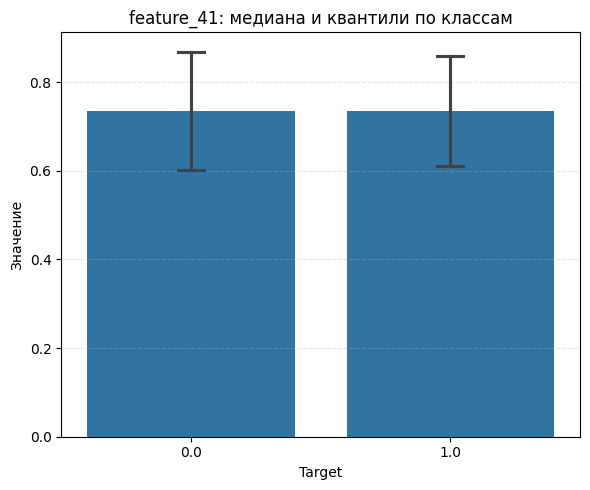

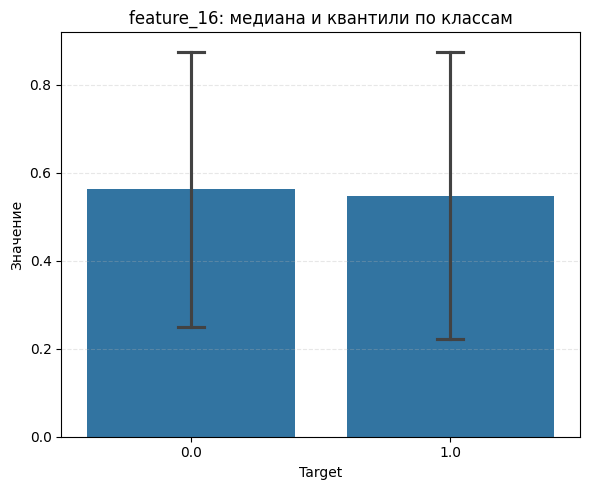

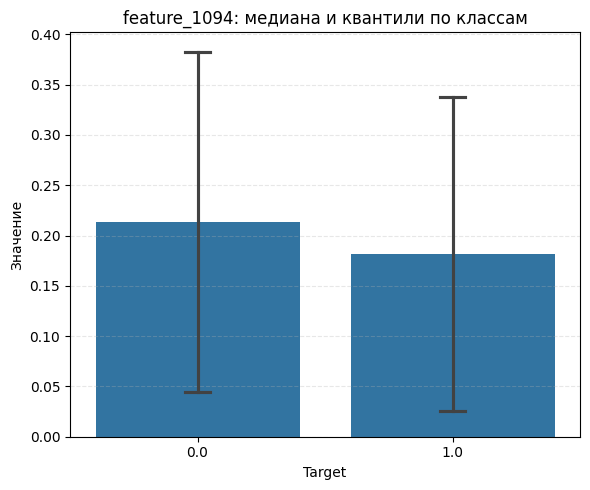

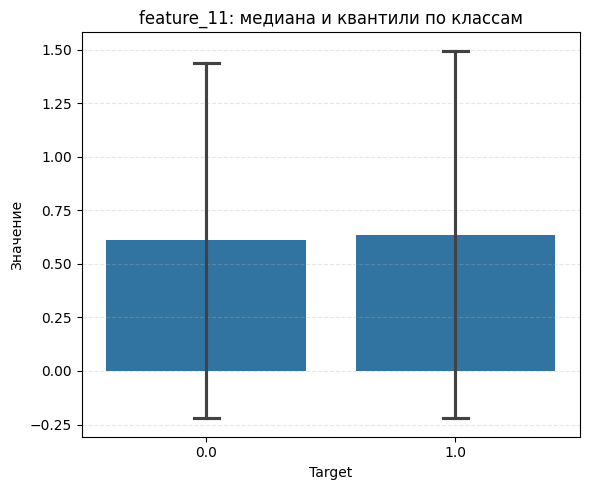

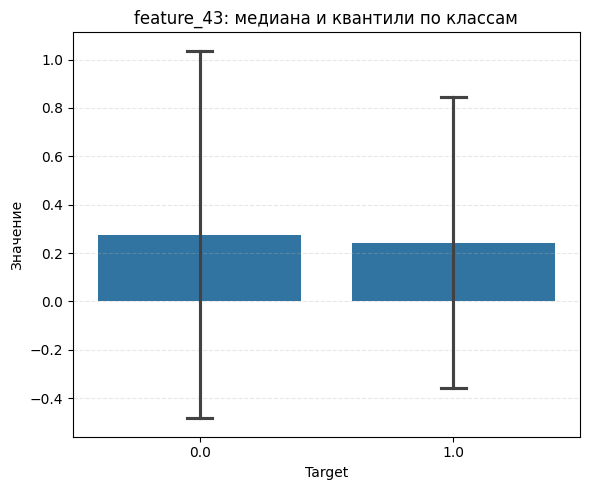

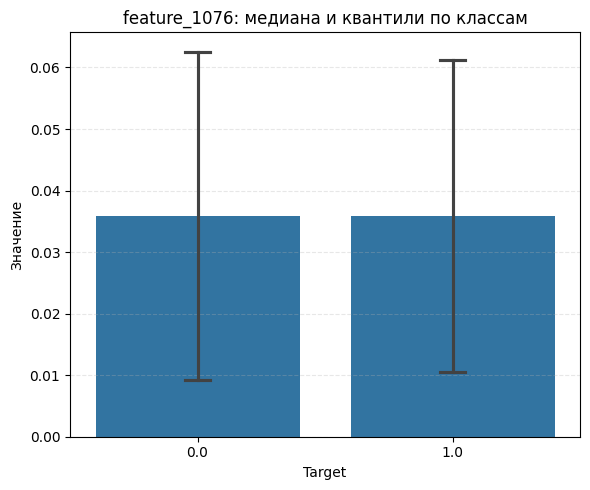

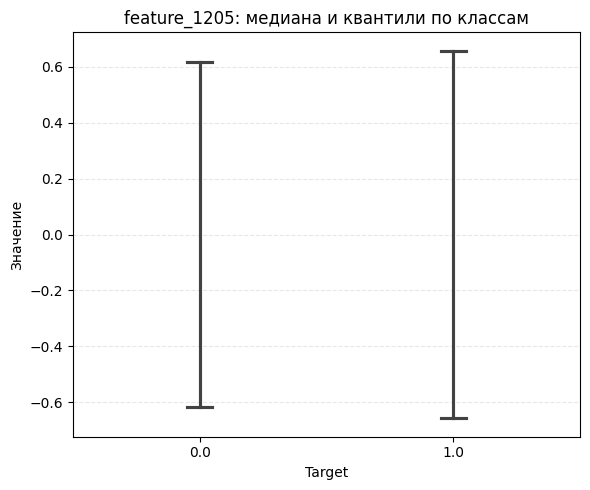

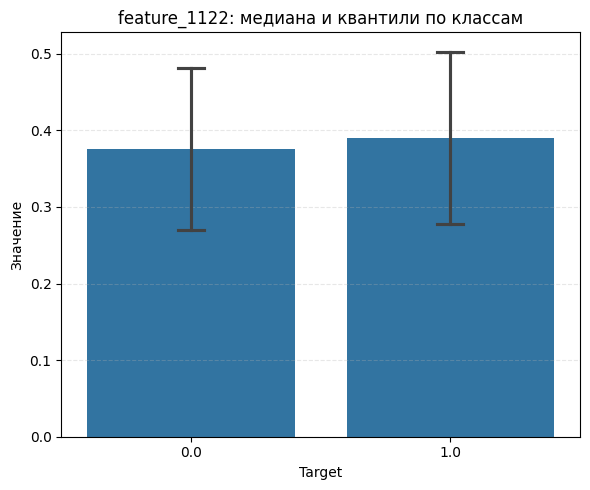

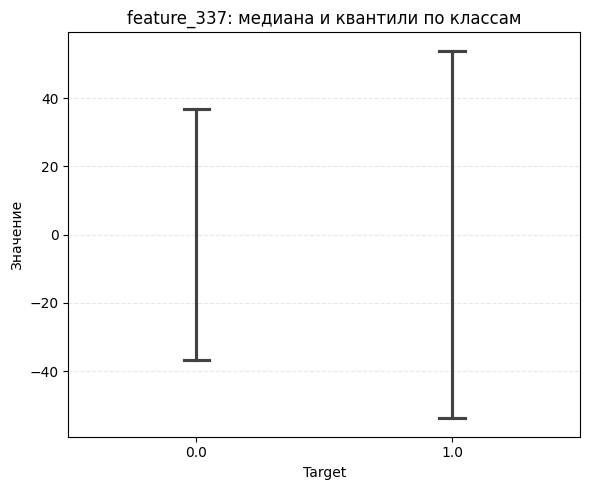

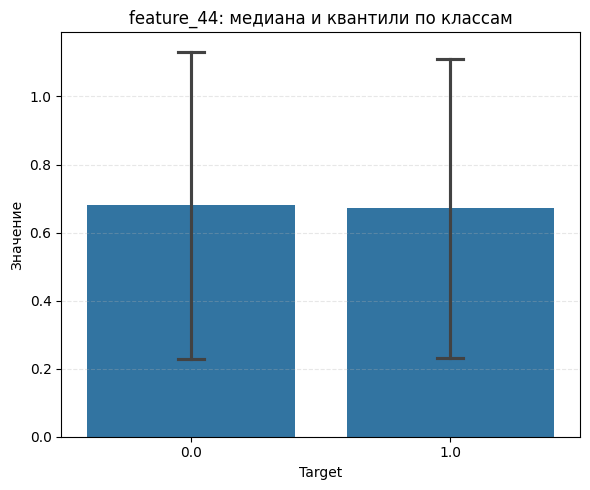

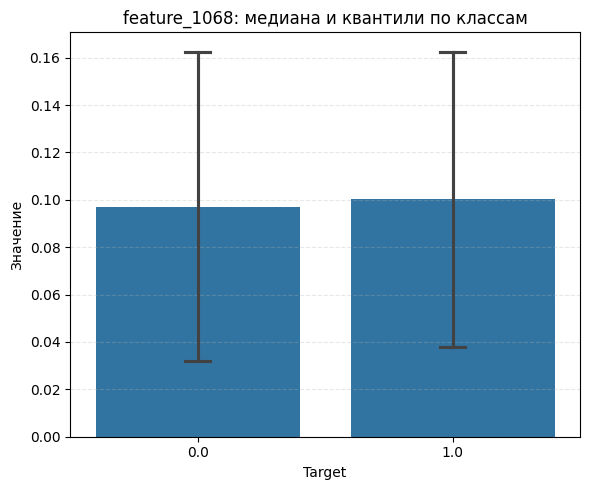

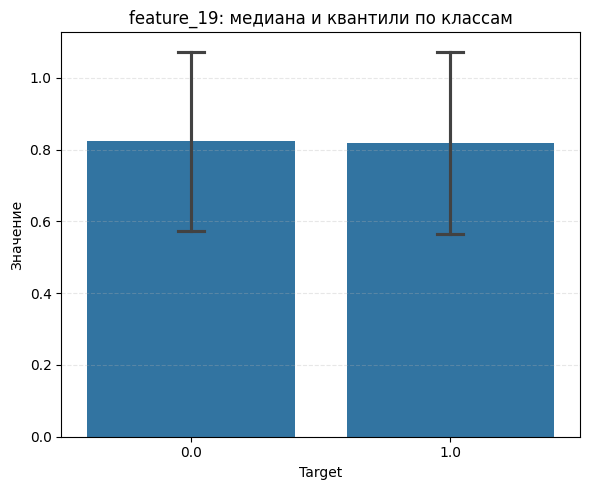

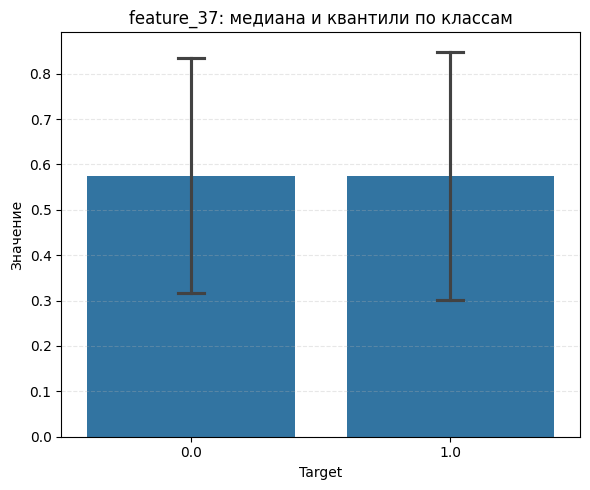

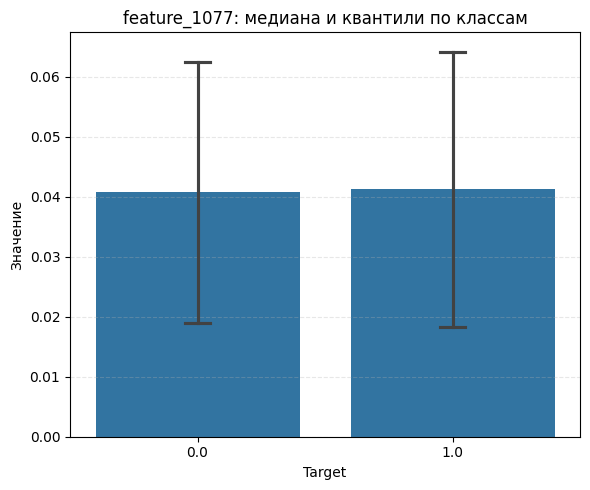

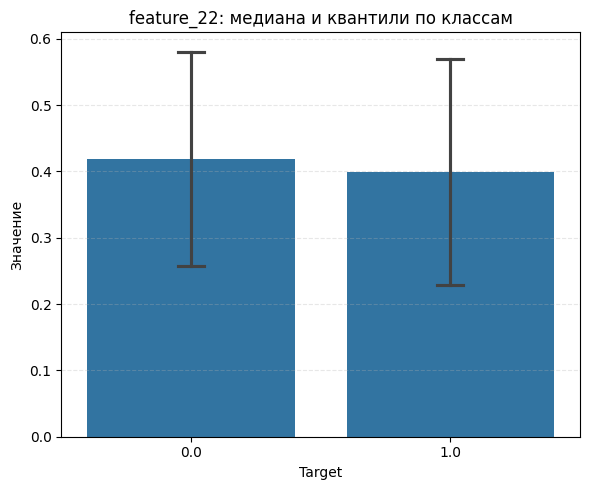

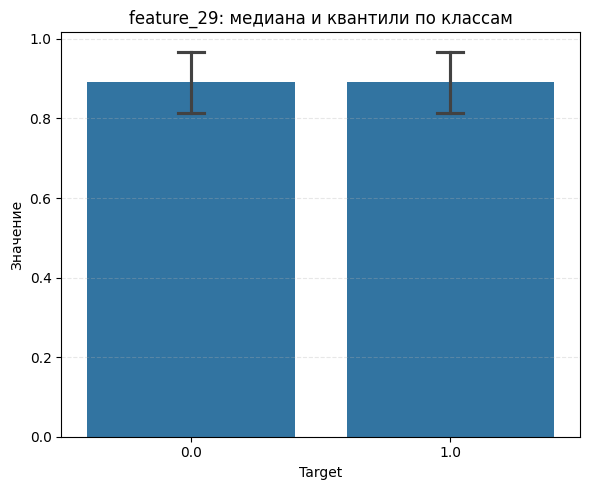

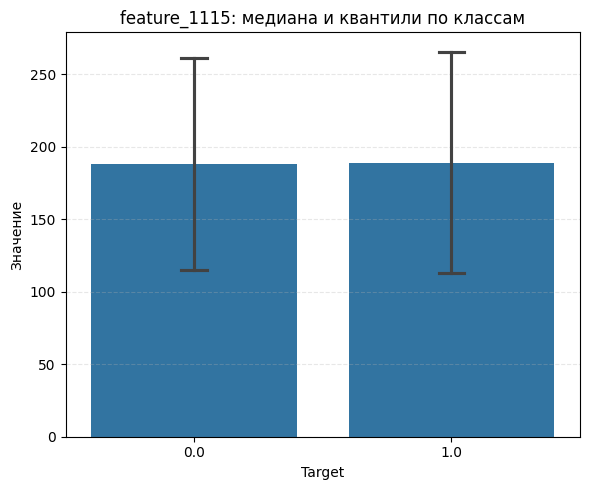

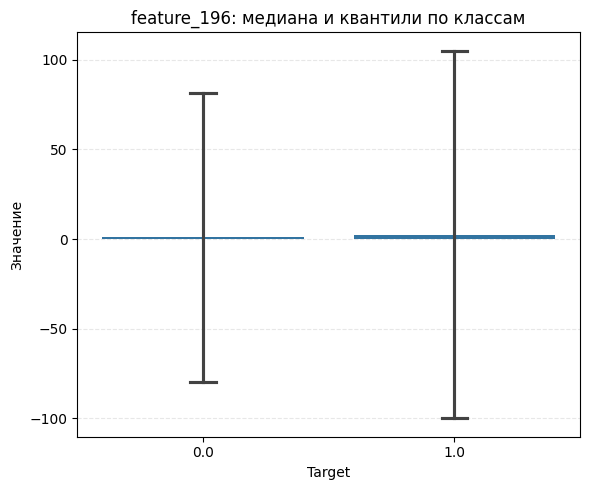

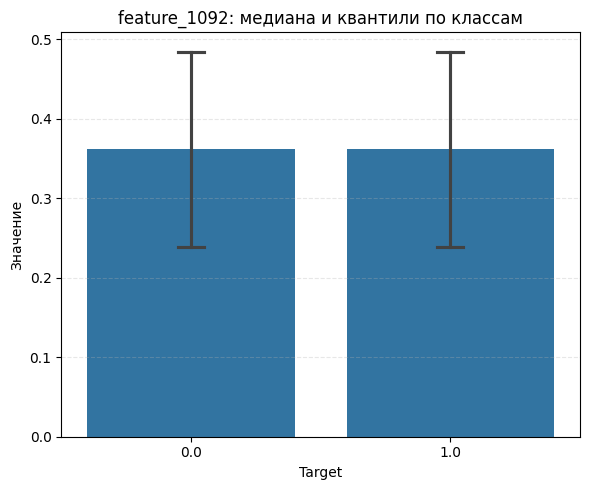

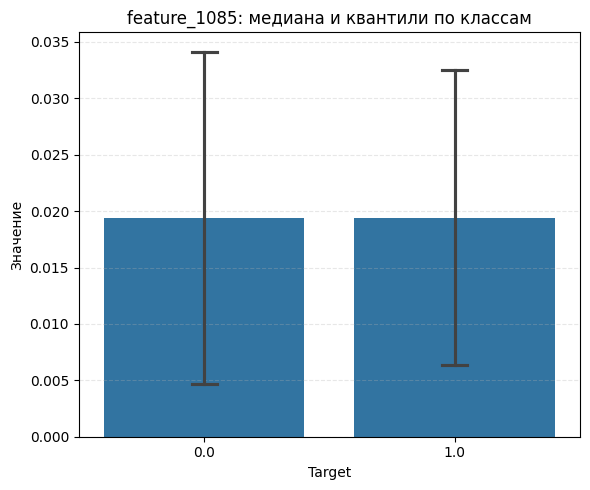

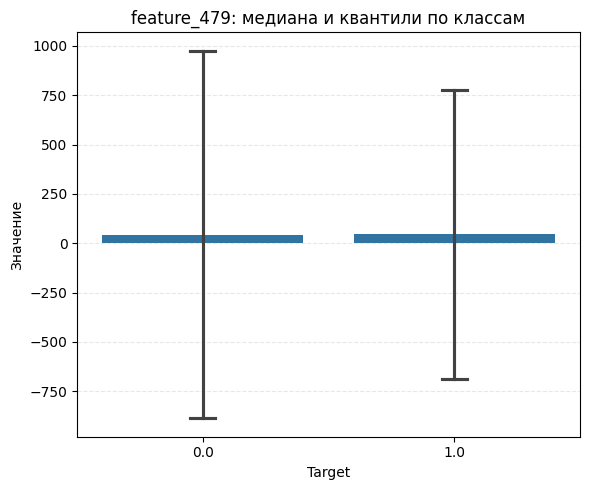

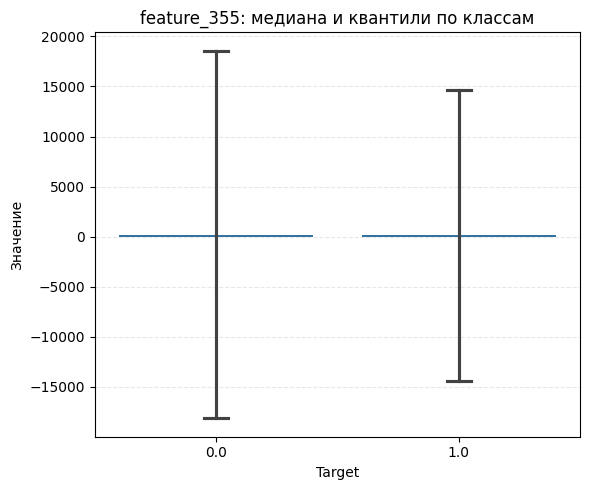

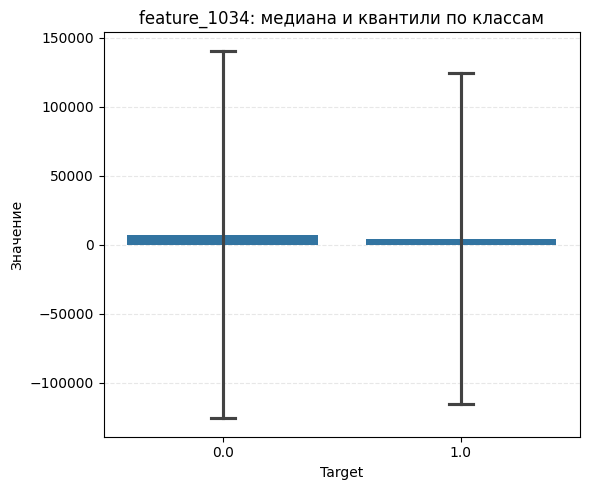

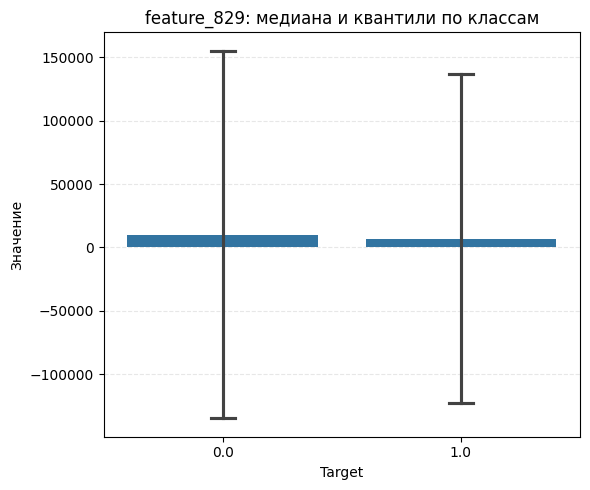

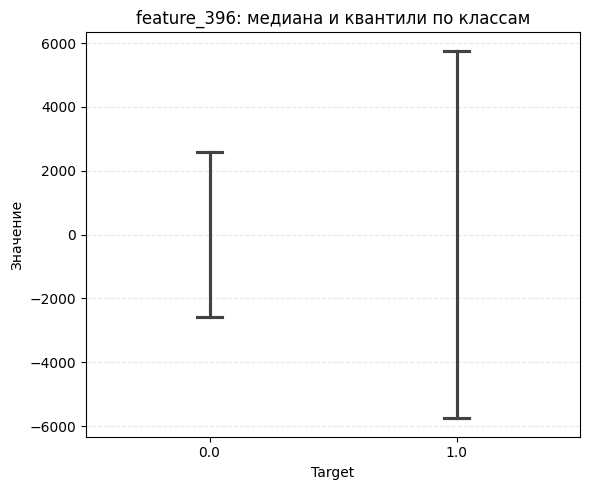

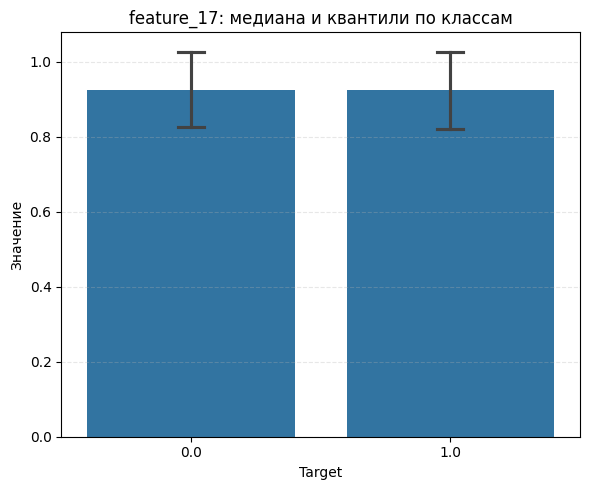

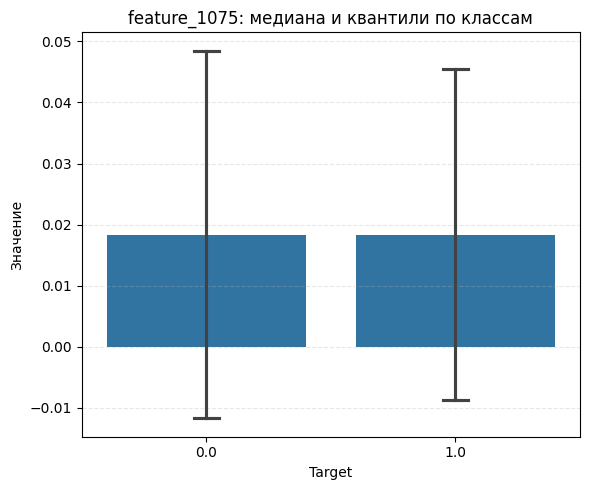

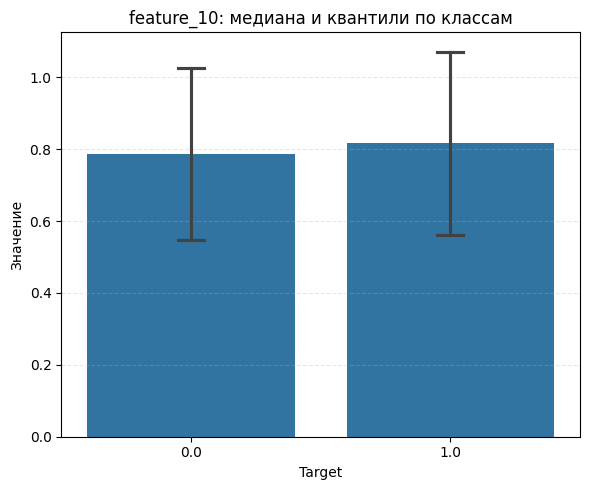

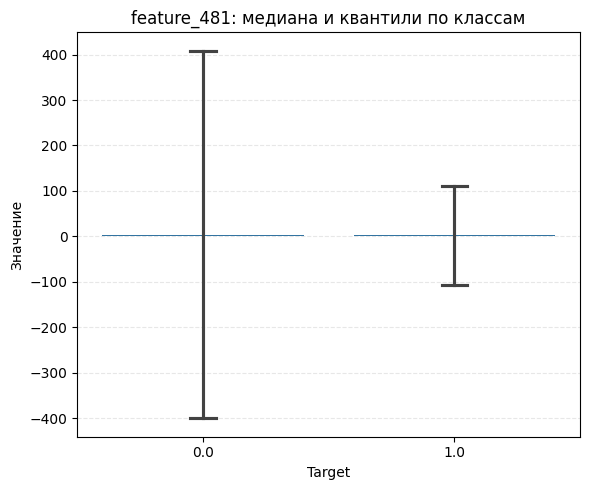

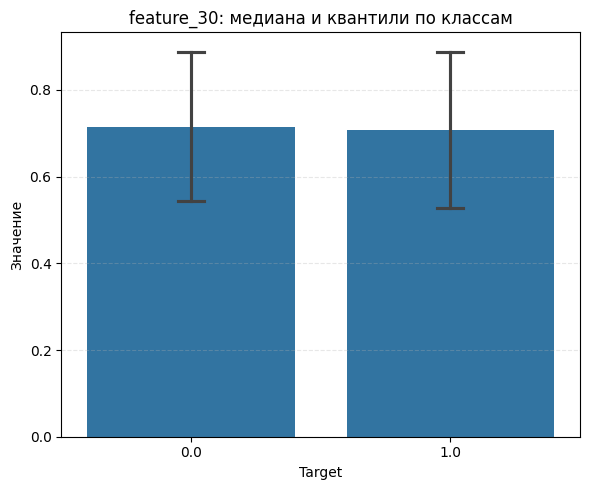

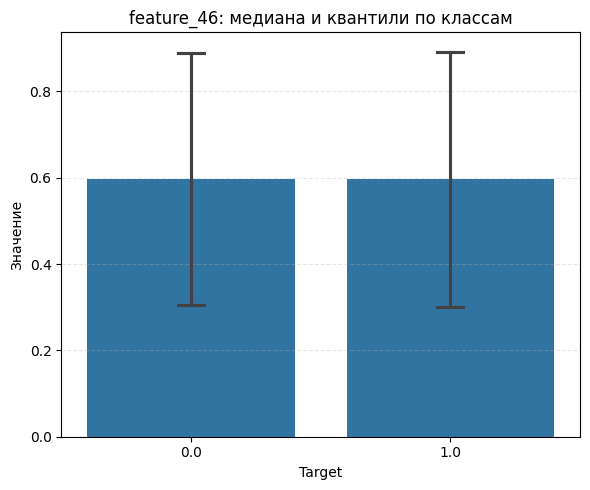

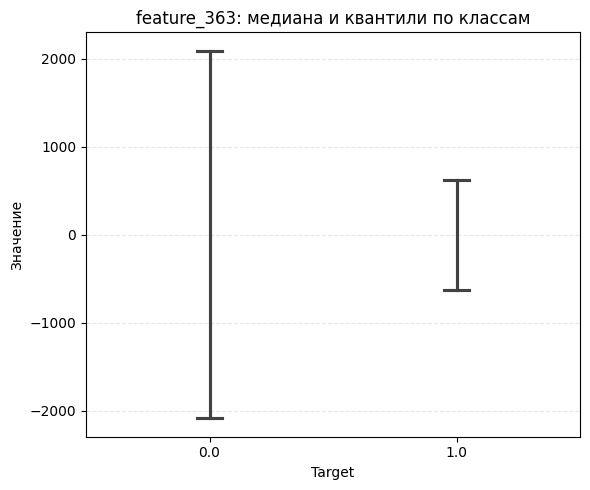

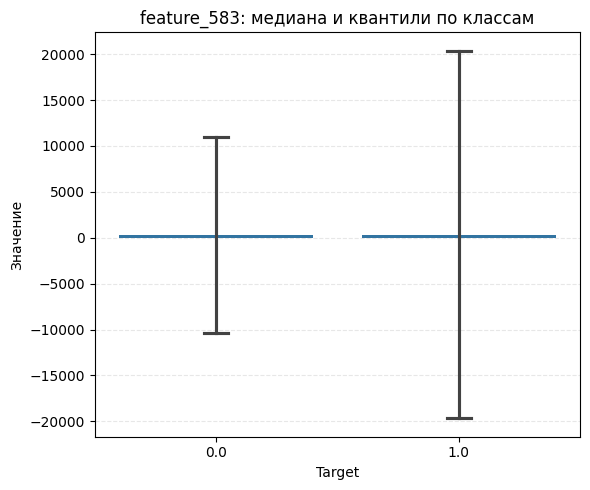

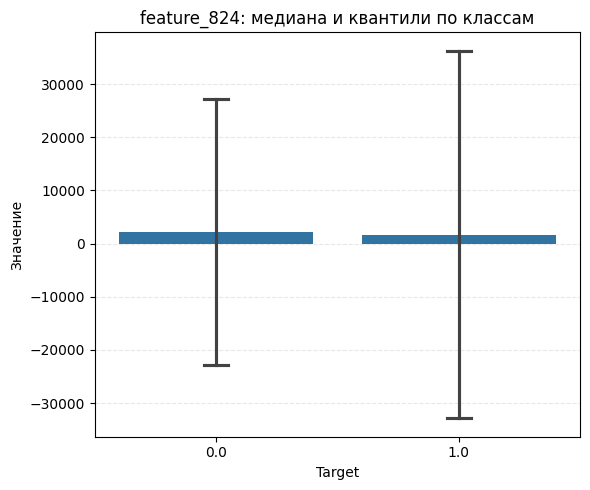

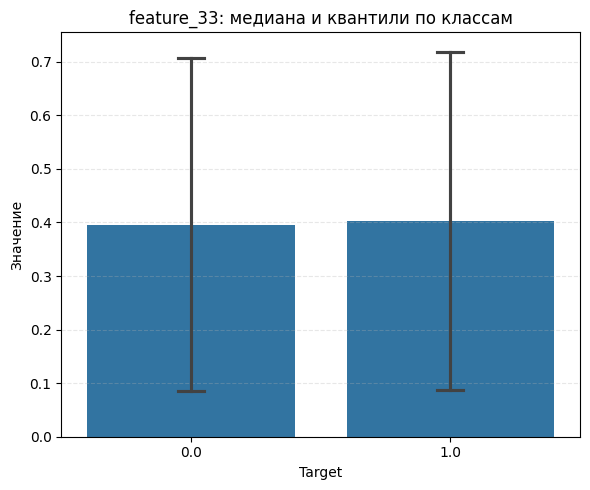

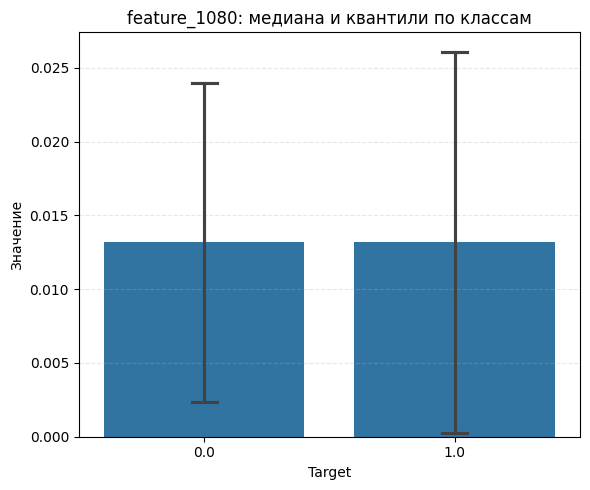

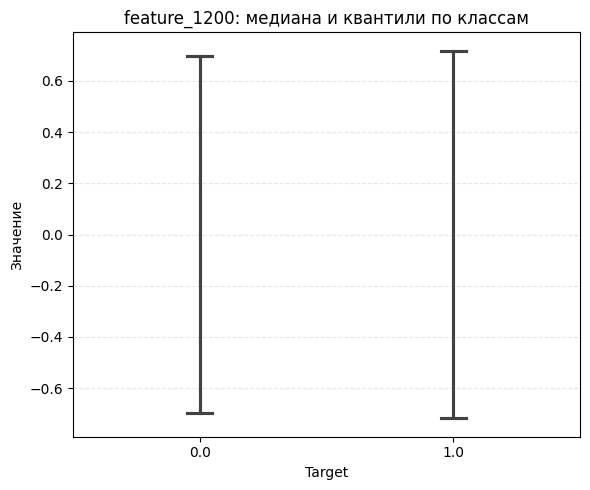

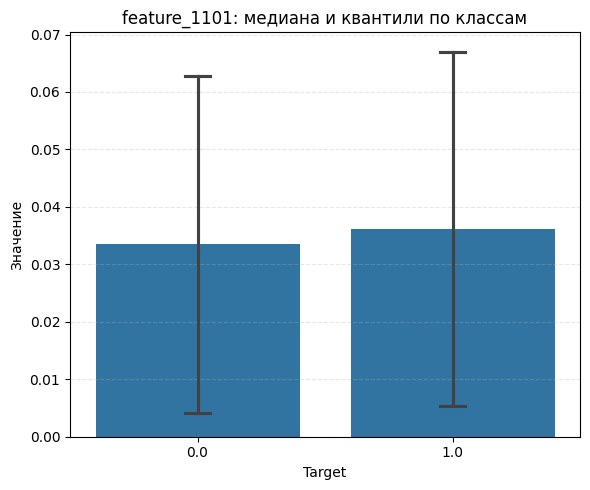

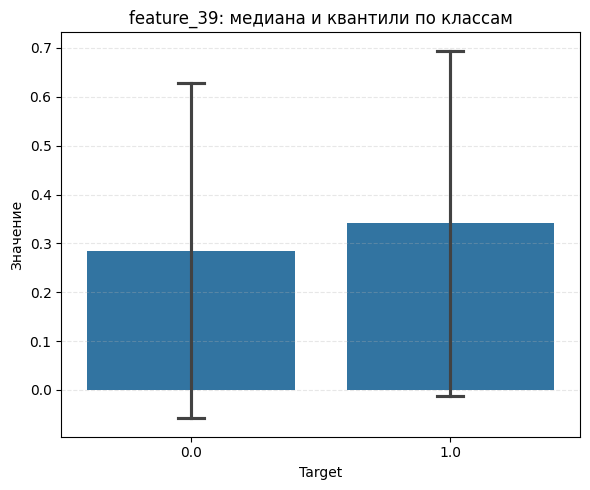

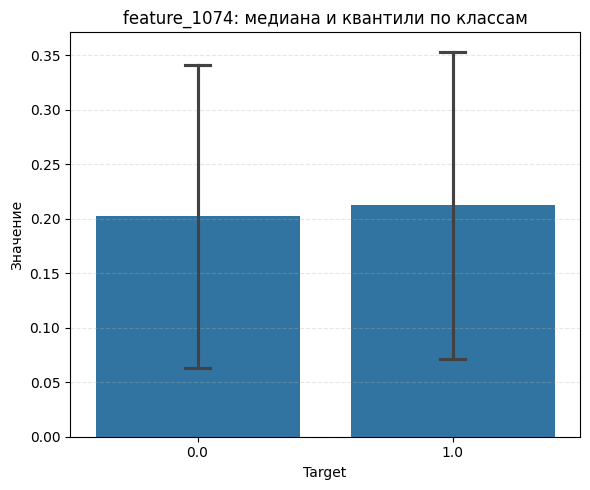

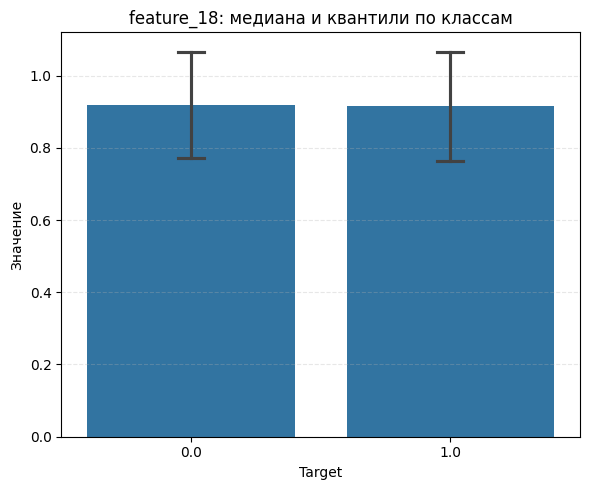

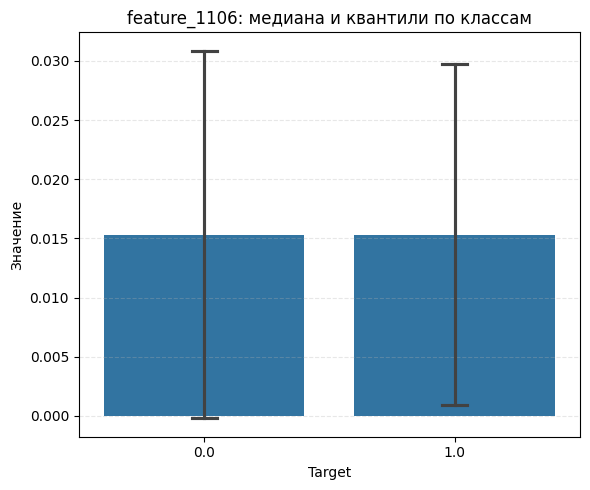

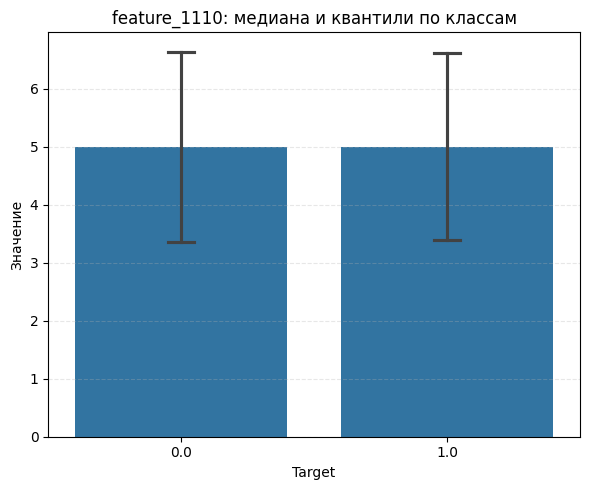

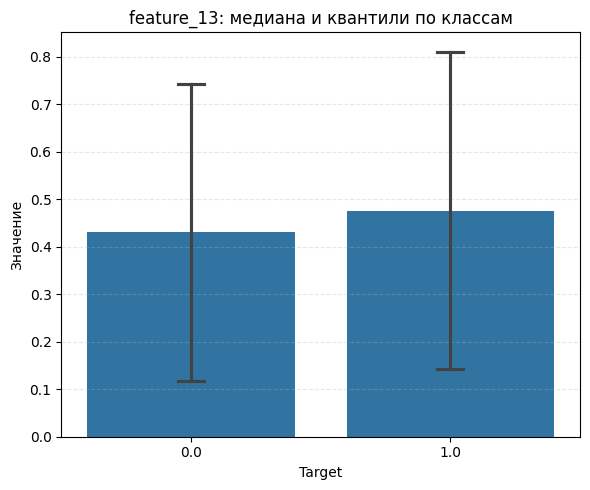

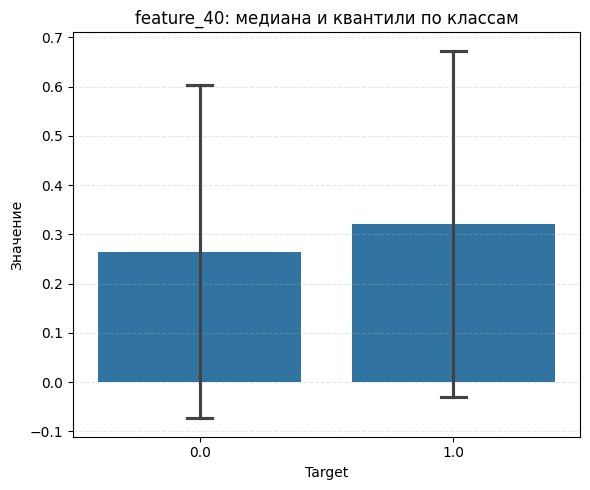

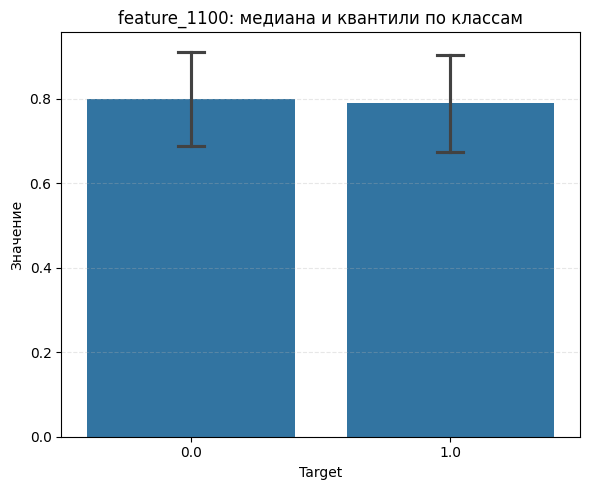

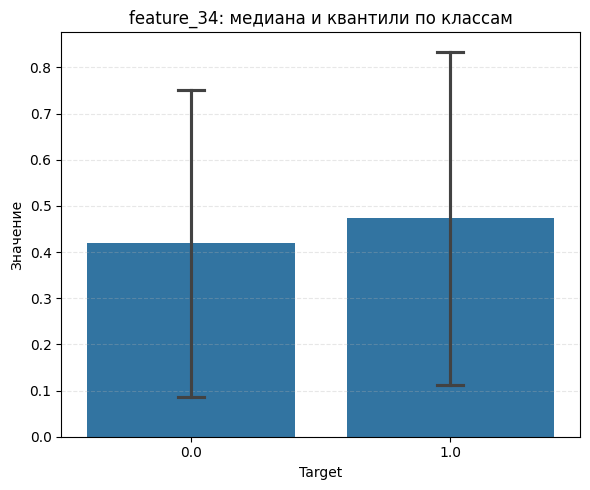

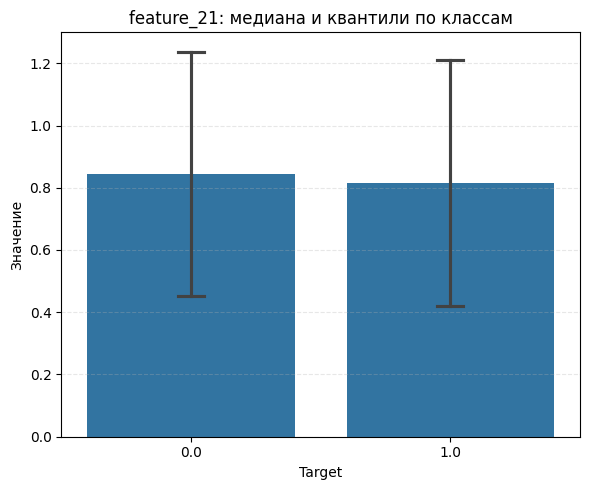

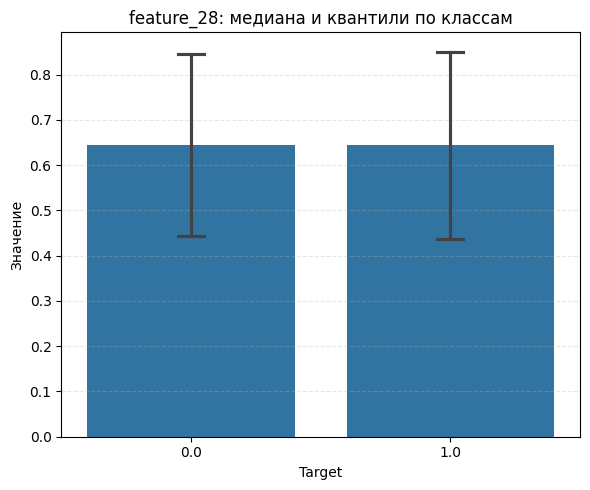

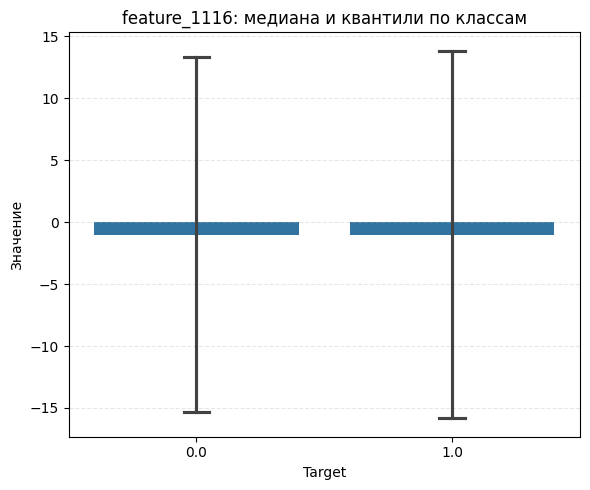

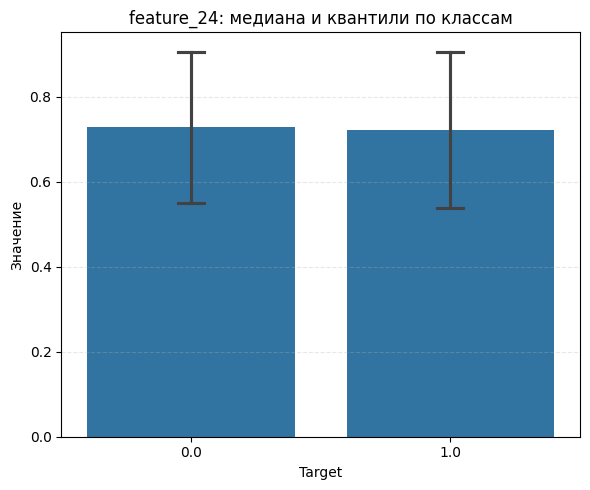

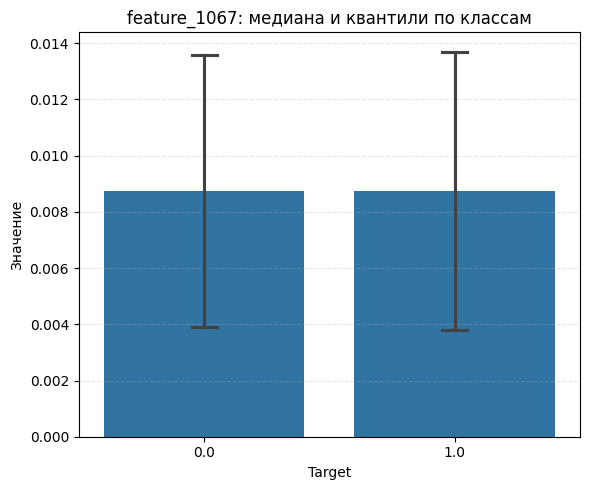

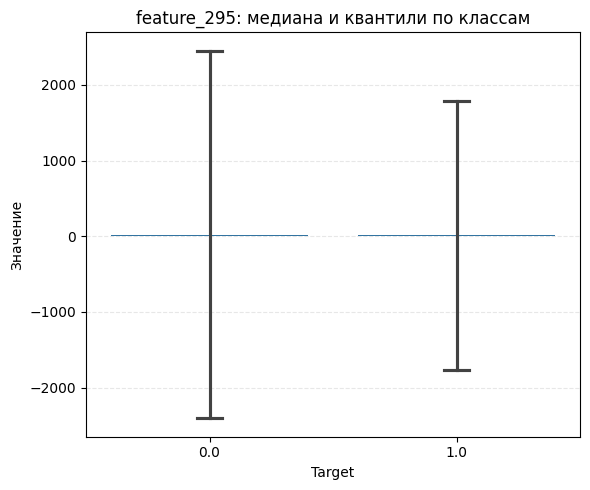

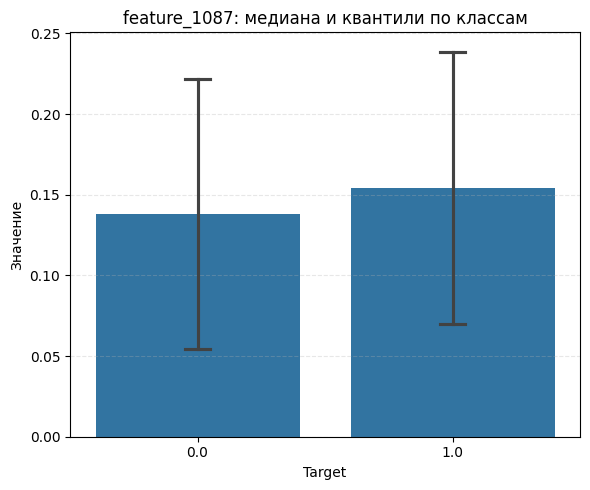

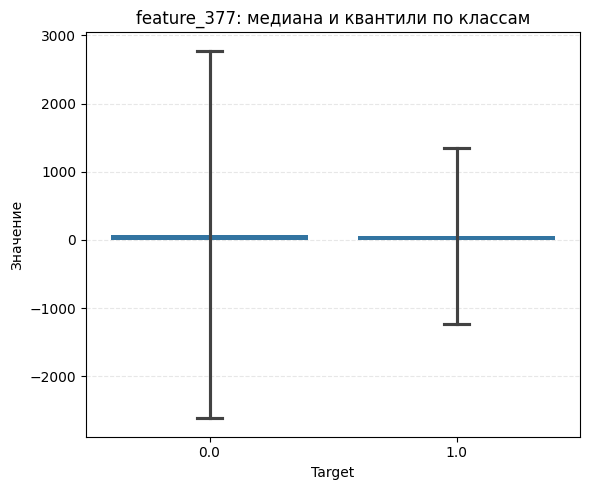

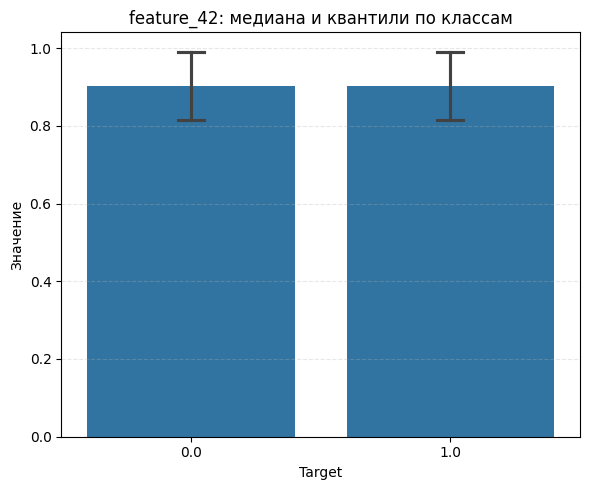

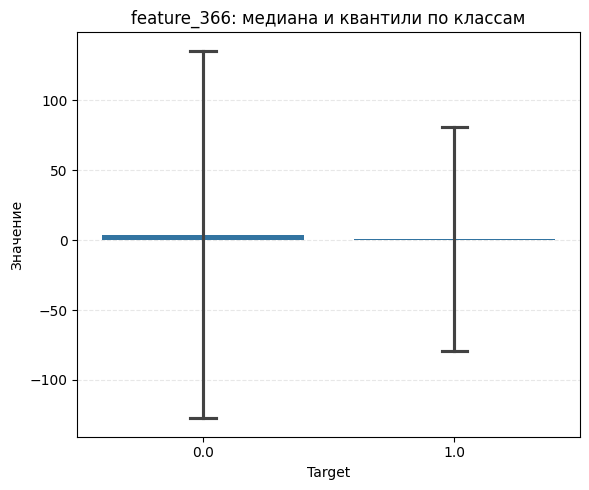

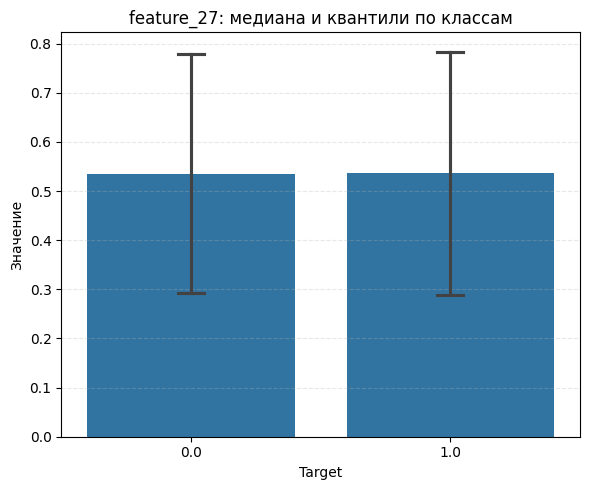

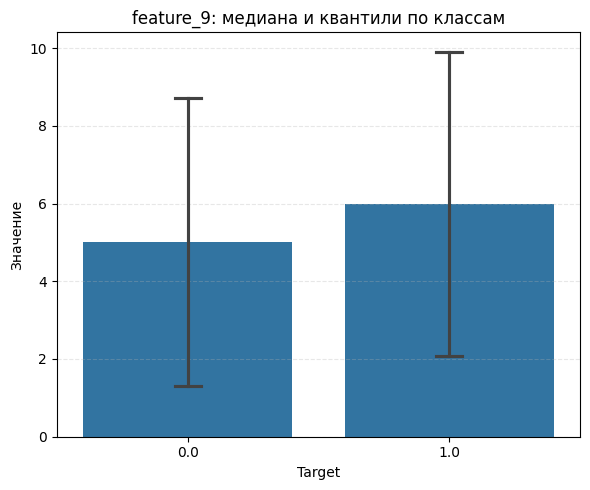

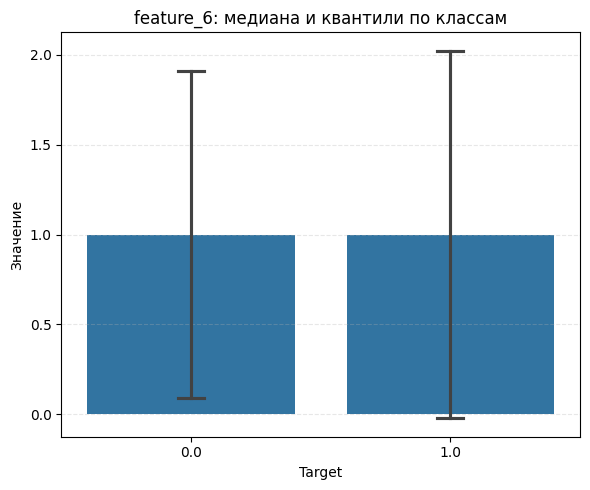

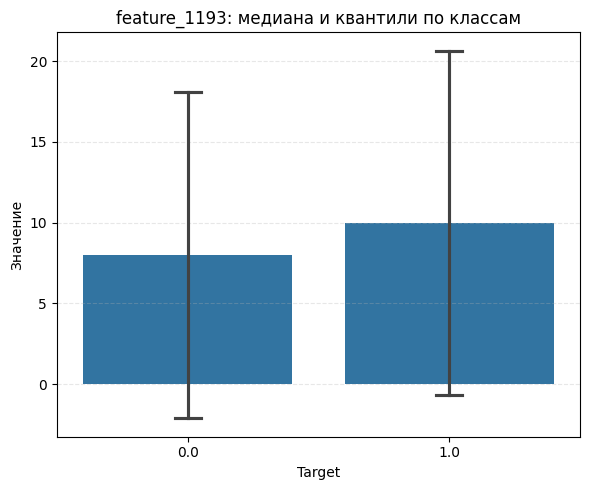

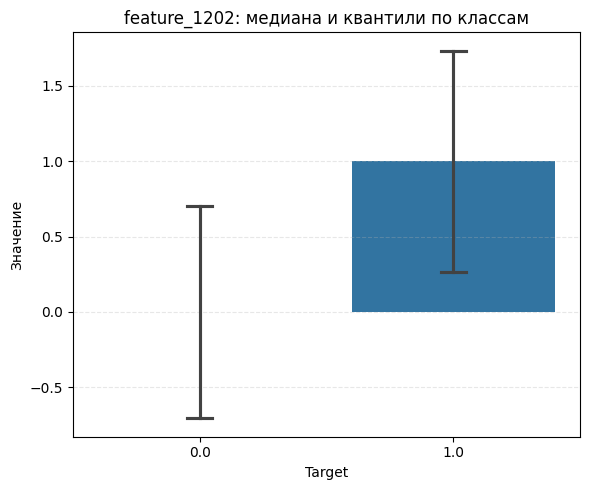

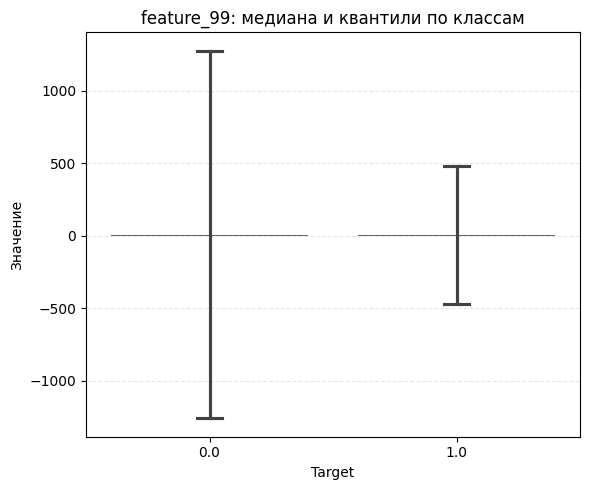

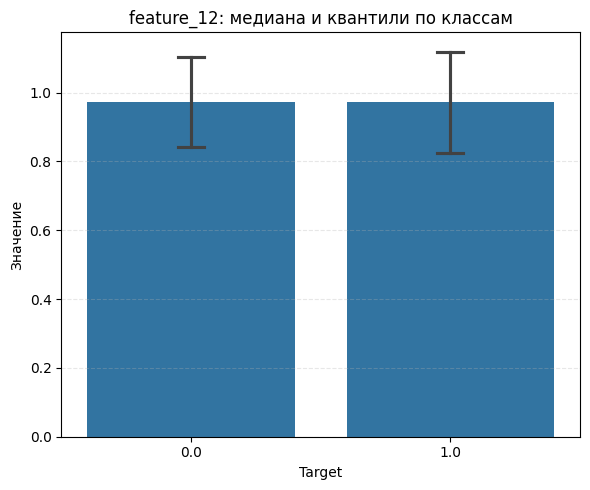

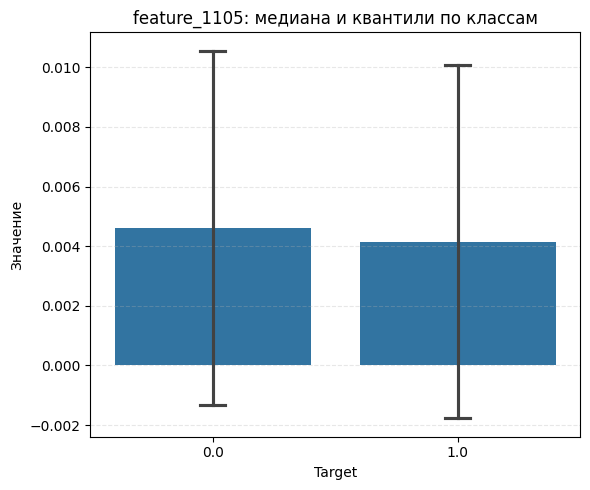

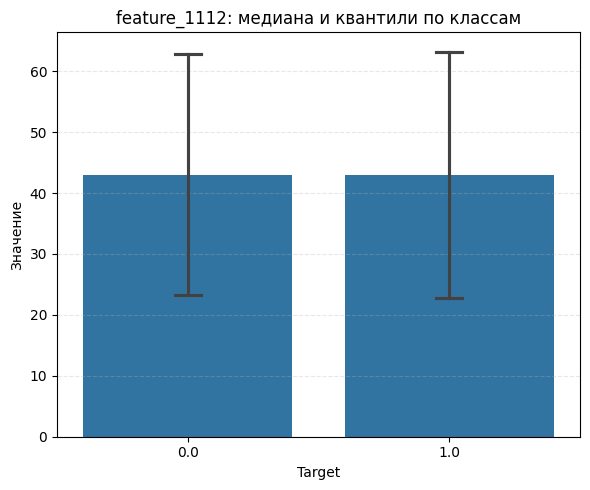

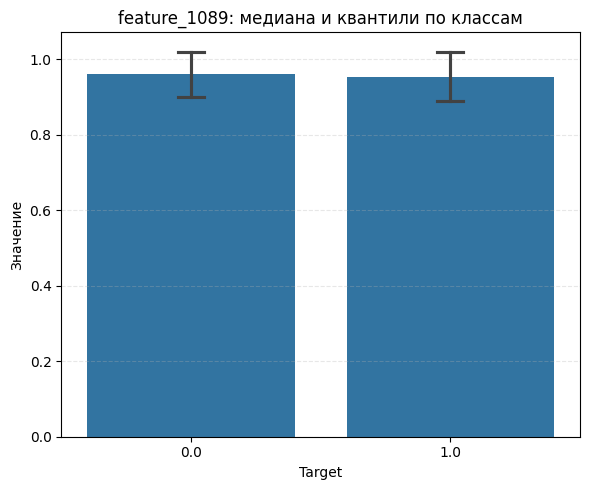

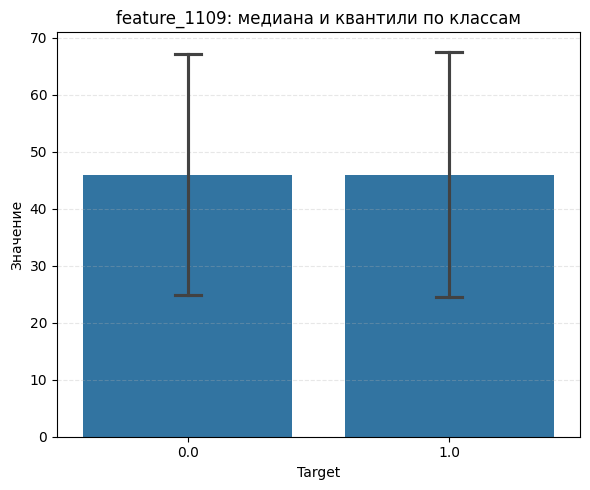

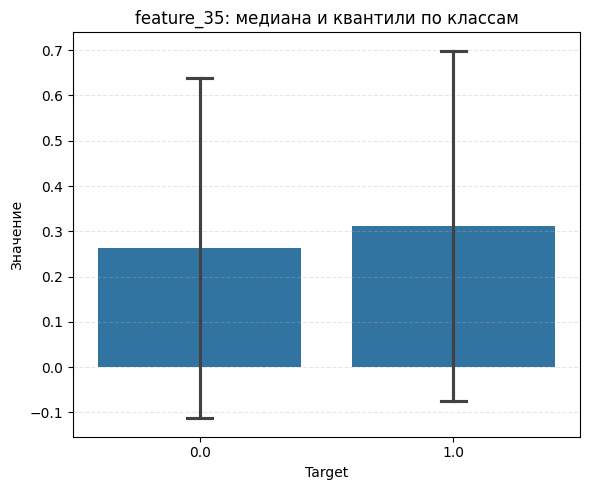

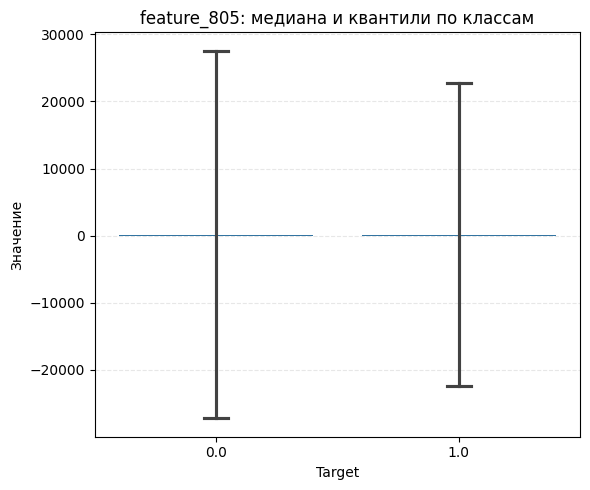

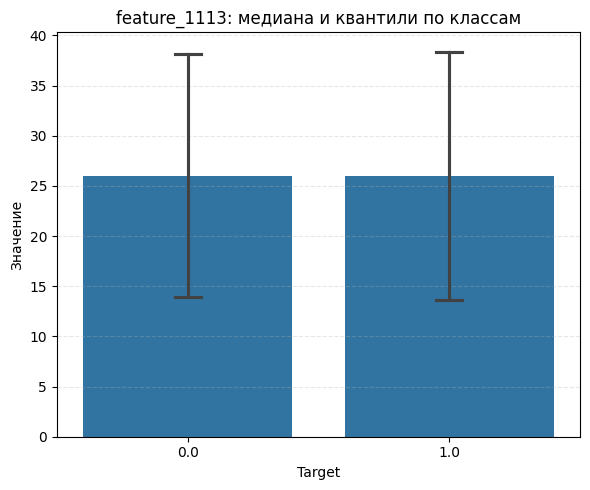

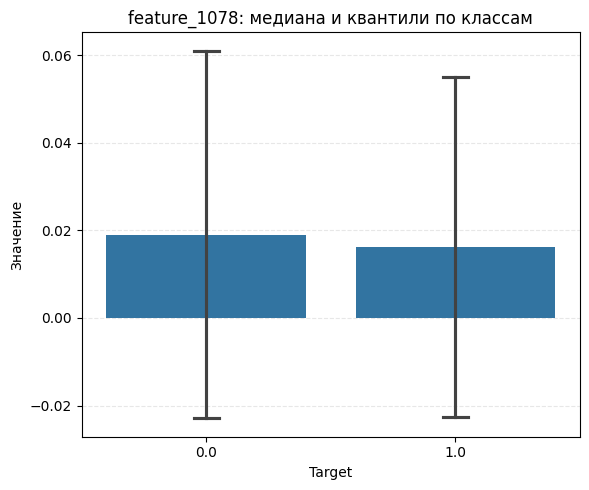

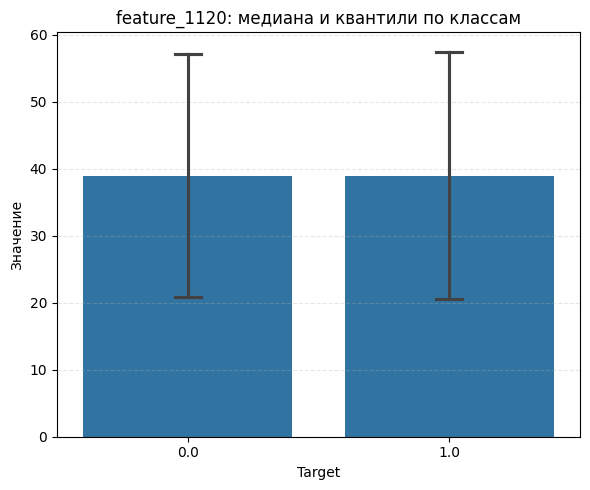

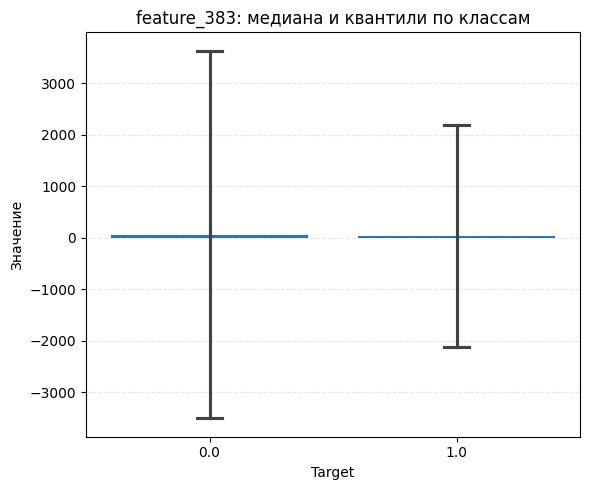

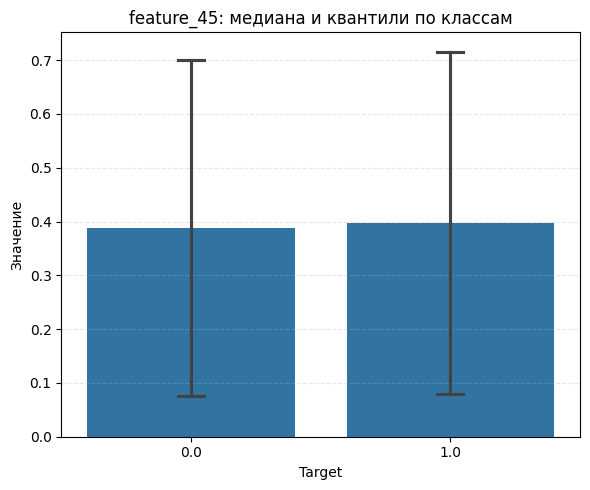

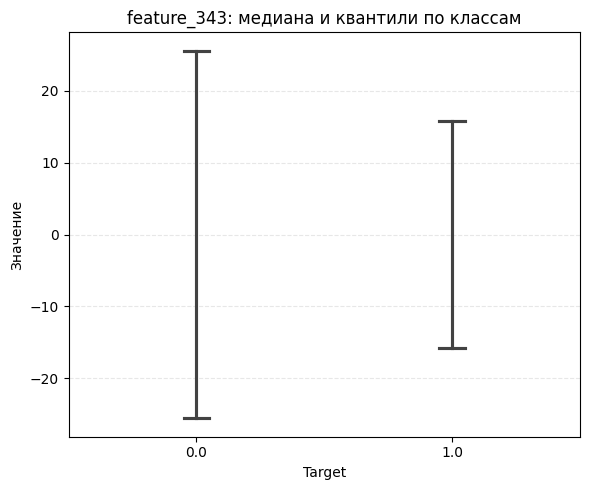

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'target'
features = df_clean.columns.drop(target_col)
q_low, q_high = 0.25, 0.75  

def median(x):
    return np.median(x.dropna())

for col in features:
    plt.figure(figsize=(6, 5))
    
    # Подготовка данных
    plot_data = df[[target_col, col]].copy().dropna(subset=[col])
    
    # Группированный барплот с медианой и квантилями
    sns.barplot(data=plot_data, x=target_col, y=col,
                estimator=median,
                errorbar=('sd'),
                capsize=0.1)
    
    plt.title(f'{col}: медиана и квантили по классам')
    plt.xlabel('Target')
    plt.ylabel('Значение')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

по всем фичам у класса 0 и 1 одинаковое распределение, у класса 1 поменьше разброс значений но это говорит только о том что объектов класса 1 меньше

чтобы поднять метрики нужно проверить разные линейные и не только комбинации признаков друг с другом с помощью PolynomialFeatures

In [2]:
df = pd.read_csv('../data/train.csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247972 entries, 0 to 247971
Columns: 1369 entries, index to feature_1366
dtypes: float64(1361), int64(8)
memory usage: 2.5 GB


In [4]:
lst = ['feature_41', 'feature_16', 'feature_1094', 'feature_11', 'feature_43', 'feature_1076', 'feature_1205', 'feature_1122', 'feature_337', 'feature_44', 'feature_1068', 'feature_19', 'feature_37', 'feature_1077', 'feature_22', 'feature_29', 'feature_1115', 'feature_196', 'feature_1092', 'feature_1085', 'feature_479', 'feature_355', 'feature_1034', 'feature_829', 'feature_396', 'feature_17', 'feature_1075', 'feature_10', 'feature_481', 'feature_30', 'feature_46', 'feature_363', 'feature_583', 'feature_824', 'feature_33', 'feature_1080', 'feature_1200', 'feature_1101', 'feature_39', 'feature_1074', 'feature_18', 'feature_1106', 'feature_1110', 'feature_13', 'feature_40', 'feature_1100', 'feature_34', 'feature_21', 'feature_28', 'feature_1116', 'feature_24', 'feature_1067', 'feature_295', 'feature_1087', 'feature_377', 'feature_42', 'feature_366', 'feature_27', 'feature_9', 'feature_6', 'feature_1193', 'feature_1202', 'feature_99', 'feature_12', 'feature_1105', 'feature_1112', 'feature_1089', 'feature_1109', 'feature_35', 'feature_805', 'feature_1113', 'feature_1078', 'feature_1120', 'feature_383', 'feature_45', 'feature_343', 'target']


In [6]:
df_imp = df[lst]
df_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247972 entries, 0 to 247971
Data columns (total 77 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   feature_41    247972 non-null  float64
 1   feature_16    247972 non-null  float64
 2   feature_1094  247972 non-null  float64
 3   feature_11    247972 non-null  float64
 4   feature_43    247972 non-null  float64
 5   feature_1076  247972 non-null  float64
 6   feature_1205  247972 non-null  float64
 7   feature_1122  247972 non-null  float64
 8   feature_337   247972 non-null  float64
 9   feature_44    247972 non-null  float64
 10  feature_1068  247972 non-null  float64
 11  feature_19    247972 non-null  float64
 12  feature_37    247972 non-null  float64
 13  feature_1077  247972 non-null  float64
 14  feature_22    247972 non-null  float64
 15  feature_29    247972 non-null  float64
 16  feature_1115  247972 non-null  float64
 17  feature_196   247972 non-null  float64
 18  feat

In [7]:
import optuna
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from optuna.integration import CatBoostPruningCallback
import warnings
warnings.filterwarnings('ignore')

X, y = df_imp.drop(['target'], axis=1), df_imp['target'] 
cat_features = []

X_part1, X_rest, y_part1, y_rest = train_test_split(
    X, y, test_size=2/3, random_state=42, stratify=y
)
X_part2, X_part3, y_part2, y_part3 = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest
)
# ✅ Part 1: ~33% → для подбора гиперпараметров (Optuna)
# ✅ Part 2: ~33% → для финального обучения модели
# ✅ Part 3: ~33% → для итогового тестирования

# 2️⃣ ФУНКЦИЯ ОПТИМИЗАЦИИ (Optuna)
def objective(trial):
    # Внутренний сплит Part 1, чтобы избежать переобучения на валидации Optuna
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_part1, y_part1, test_size=0.2, random_state=42, stratify=y_part1
    )
    
    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    val_pool   = Pool(X_va, y_va, cat_features=cat_features)

    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'border_count': trial.suggest_int('border_count', 64, 255, step=32),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 10),
        'eval_metric': 'AUC',
        'verbose': False,
        'random_state': 42
    }

    # Pruning останавливает trial, если AUC не растёт
    pruning_cb = CatBoostPruningCallback(trial, metric='AUC')

    model = CatBoostClassifier(**params)
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
        use_best_model=True,
        callbacks=[pruning_cb]
    )

    pred_proba = model.predict_proba(X_va)[:, 1]
    return roc_auc_score(y_va, pred_proba)  # Optuna будет максимизировать это значение

# 3️⃣ ЗАПУСК OPTUNA
study = optuna.create_study(
    direction='maximize',  # 🎯 ROC AUC максимизируем
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
)

print("🔍 Запуск подбора гиперпараметров на Part 1...")
study.optimize(objective, n_trials=50, timeout=3600, show_progress_bar=True)

# 4️⃣ ИТОГИ ПОДБОРА
print("\n✅ Лучший trial:")
trial = study.best_trial
print(f"   ROC AUC (val): {trial.value:.4f}")
for k, v in trial.params.items():
    print(f"   {k}: {v}")

# 5️⃣ ФИНАЛЬНОЕ ОБУЧЕНИЕ НА PART 2
best_params = trial.params.copy()
# Убираем служебные ключи, которые не нужны в конструкторе финальной модели
for k in ['eval_metric', 'verbose', 'random_state']:
    best_params.pop(k, None)

train_pool_final = Pool(X_part2, y_part2, cat_features=cat_features)

final_model = CatBoostClassifier(
    **best_params,
    eval_metric='AUC',
    verbose=100,
    random_state=42
)
print("\n🏋️ Обучение финальной модели на Part 2...")
final_model.fit(train_pool_final)  # Без eval_set, т.к. обучаем строго на Part 2

# 6️⃣ ТЕСТИРОВАНИЕ НА PART 3
y_pred_proba = final_model.predict_proba(X_part3)[:, 1]
final_auc = roc_auc_score(y_part3, y_pred_proba)

print(f"\n📊 Итоговый ROC AUC на Part 3 (тест): {final_auc:.4f}")

# Сохранение
final_model.save_model('catboost_auc_best.cbm')

[I 2026-05-26 13:31:23,681] A new study created in memory with name: no-name-2df250a6-25a0-4134-b1d5-962fdbeec68f


🔍 Запуск подбора гиперпараметров на Part 1...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-26 13:31:26,365] Trial 0 finished with value: 0.5980313766615424 and parameters: {'iterations': 700, 'learning_rate': 0.22648248189516848, 'depth': 9, 'l2_leaf_reg': 0.24810409748678125, 'bagging_temperature': 0.15601864044243652, 'random_strength': 3.630322466779864e-08, 'min_data_in_leaf': 2, 'subsample': 0.9330880728874675, 'colsample_bylevel': 0.8005575058716043, 'border_count': 192, 'one_hot_max_size': 2}. Best is trial 0 with value: 0.5980313766615424.
[I 2026-05-26 13:31:28,009] Trial 1 finished with value: 0.6147305938810094 and parameters: {'iterations': 1500, 'learning_rate': 0.11536162338241392, 'depth': 5, 'l2_leaf_reg': 0.005337032762603957, 'bagging_temperature': 0.18340450985343382, 'random_strength': 1.1026112761510023e-06, 'min_data_in_leaf': 11, 'subsample': 0.7159725093210578, 'colsample_bylevel': 0.645614570099021, 'border_count': 160, 'one_hot_max_size': 3}. Best is trial 1 with value: 0.6147305938810094.
[I 2026-05-26 13:31:29,532] Trial 2 finished with

In [ ]:
loaded_model = CatBoostClassifier()
loaded_model.load_model("catboost_best_model.cbm")

y_pred_proba = loaded_model.predict_proba(X_part3)[:, 1]
final_auc = roc_auc_score(y_part3, y_pred_proba)

print(f"\n📊 Итоговый ROC AUC на Part 3 (тест): {final_auc:.4f}")